# EDA (Exploratory data analytics)

In [1]:
import pandas as pd
df = pd.read_csv("cleaned_churn_data.csv")
display(df)

,creditscore,geography,gender,age,tenure(no_of_year_stay),balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [2]:
# show unique values ineach columns
for column in df.columns:
    val = df[column].unique()
    print(f" {column}: {val}")

 creditscore: [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734 644
 626 649 805 718 840 630 654 762 568 613 522 737 648 443 640 540 460 593
 801 611 802 745 483 690 492 709 705 

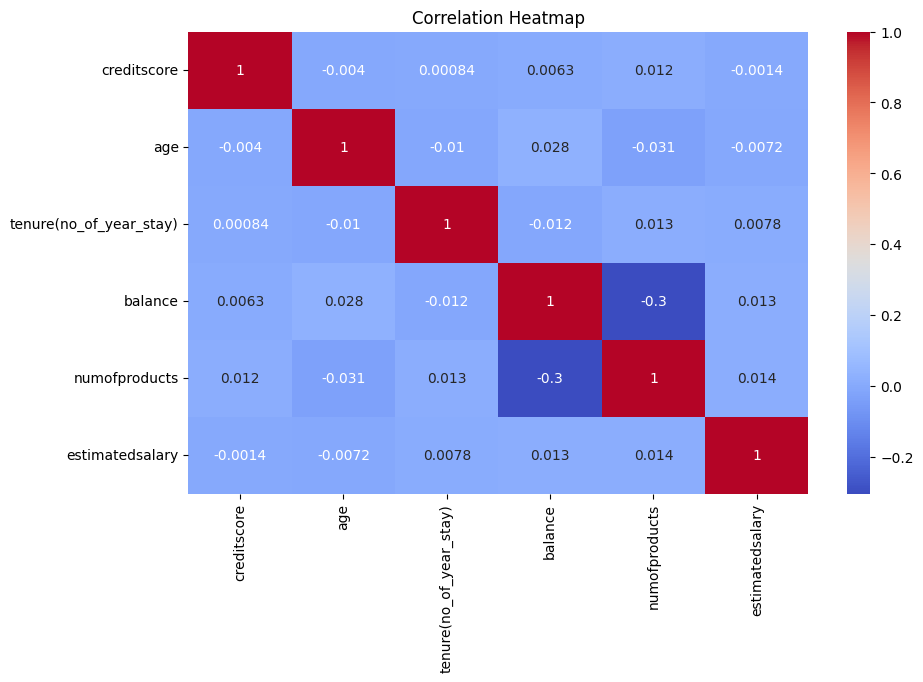

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_col=["creditscore" , "age" , "tenure(no_of_year_stay)","balance","numofproducts","estimatedsalary"]
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_col].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

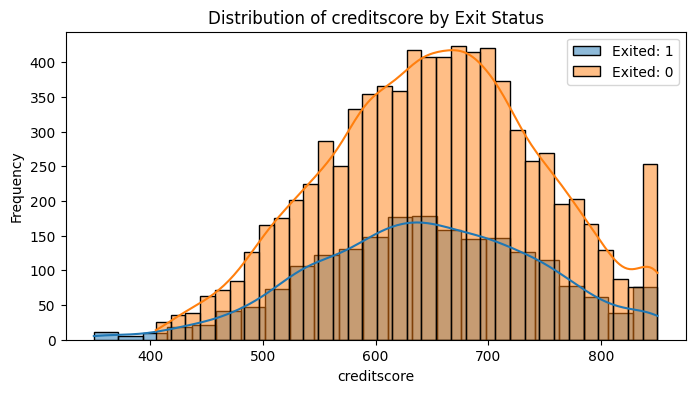

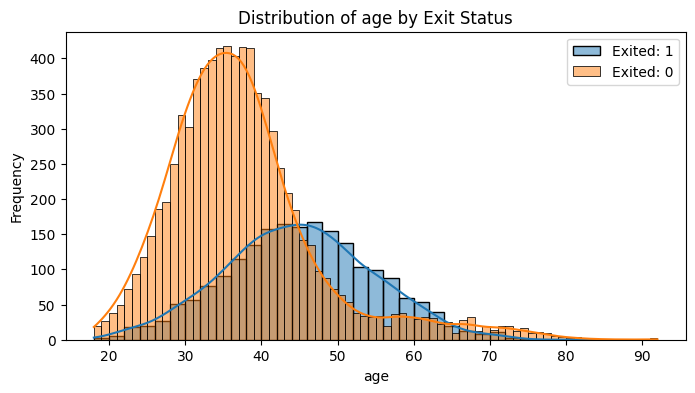

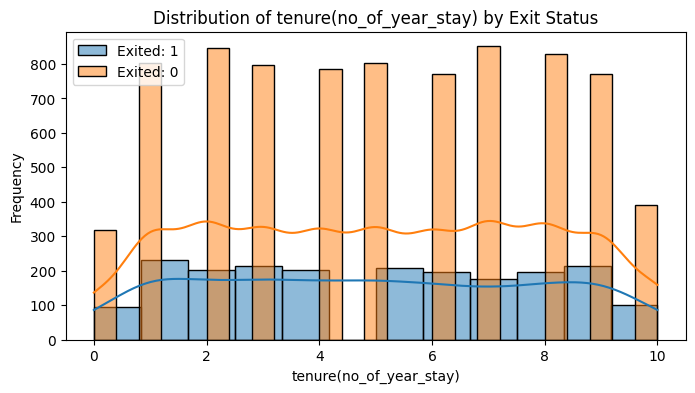

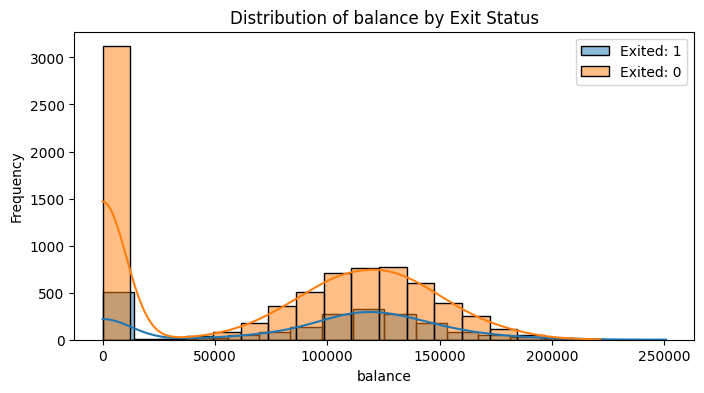

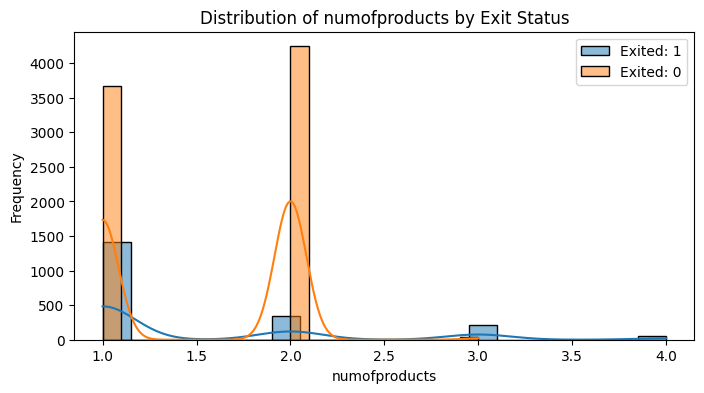

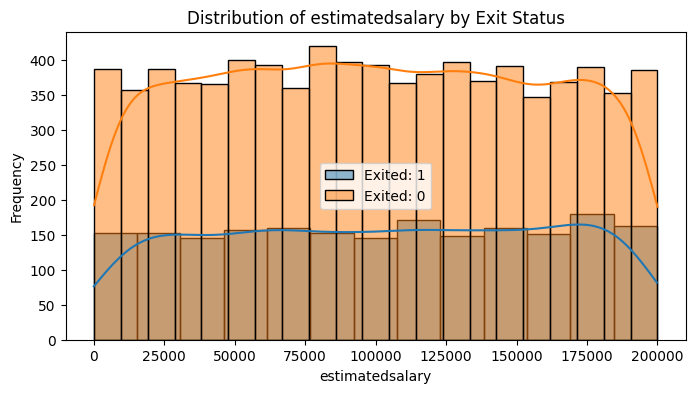

In [4]:
# distribution plot for numeric columns by exit columns
for col in numeric_col:
    plt.figure(figsize=(8,4))
    for exit_status in df["exited"].unique():
        sns.histplot(df[df["exited"] == exit_status][col], kde=True, label=f"Exited: {exit_status}")
    plt.title(f"Distribution of {col} by Exit Status")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [5]:
# gender wise churn distriution
gender_churn = df.groupby("gender")["exited"].mean()
gender_churn

gender
Female    0.250715
Male      0.164559
Name: exited, dtype: float64

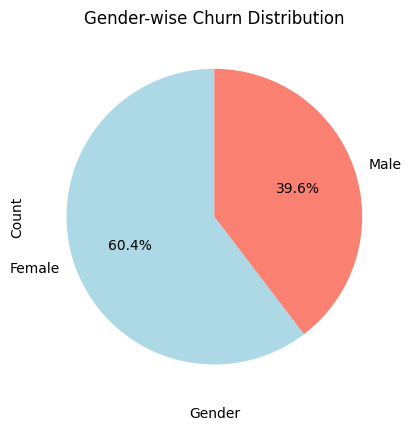

In [6]:
# plot
gender_churn.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])

plt.title("Gender-wise Churn Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

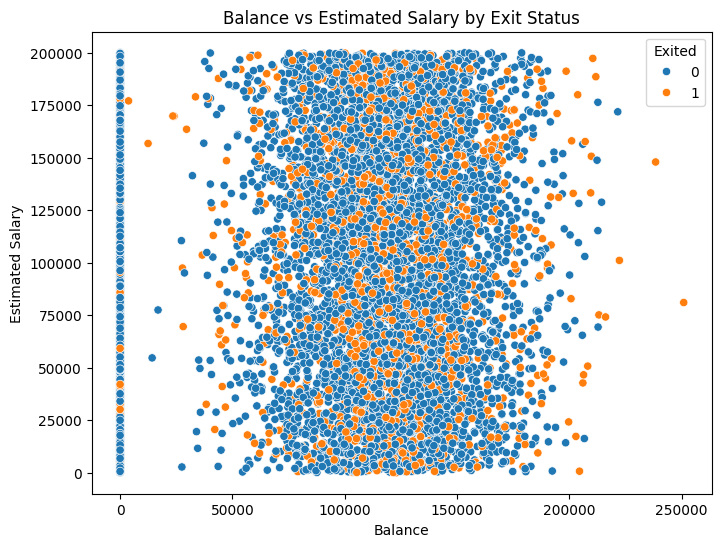

In [7]:
# balance and estimated salary distribution in scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="balance", y="estimatedsalary", hue="exited")
plt.title("Balance vs Estimated Salary by Exit Status")
plt.xlabel("Balance")
plt.ylabel("Estimated Salary")
plt.legend(title="Exited")
plt.show()

In [8]:
geography_churn = df.groupby(["geography" , "gender"])["exited"].value_counts().unstack()
geography_churn

exited               0    1
geography gender           
France    Female  1801  460
          Male    2403  350
Germany   Female   745  448
          Male     950  366
Spain     Female   858  231
          Male    1206  182

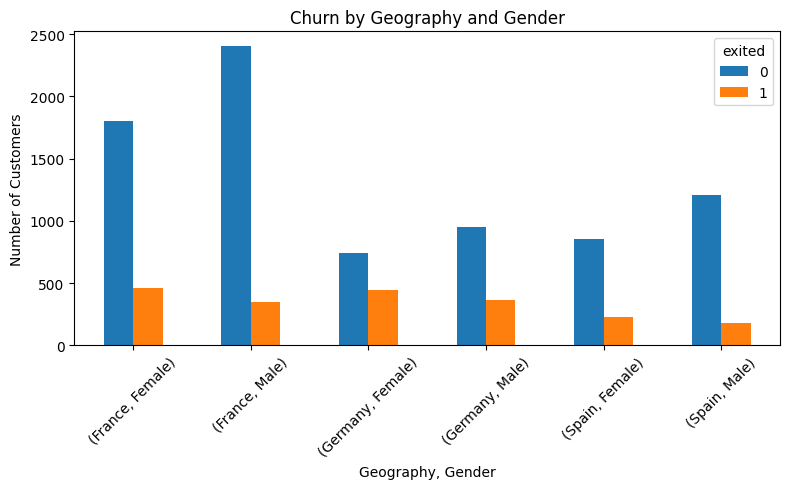

In [9]:
ax = geography_churn.plot(
    kind="bar",
    figsize=(8, 5),
    title="Churn by Geography and Gender"
)

ax.set_xlabel("Geography, Gender")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
credit_card_churn = df.groupby(["hascrcard" , "gender"])["exited"].value_counts().unstack()
credit_card_churn

exited               0    1
hascrcard gender           
0         Female  1007  344
          Male    1325  269
1         Female  2397  795
          Male    3234  629

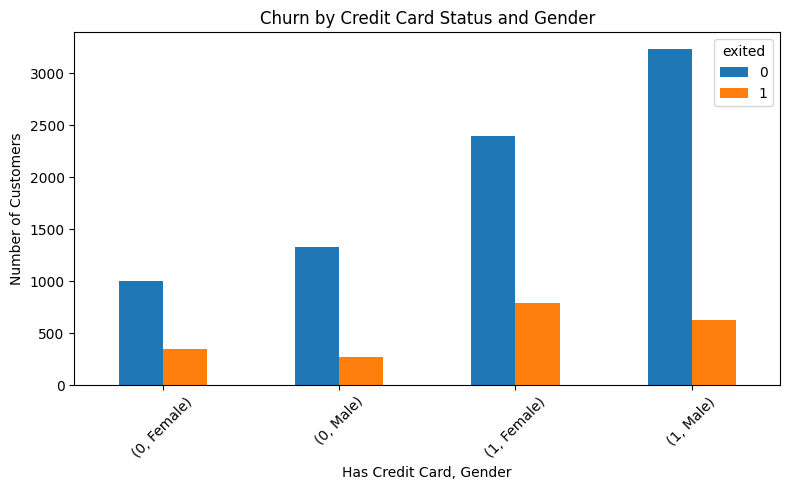

In [11]:
import matplotlib.pyplot as plt
ax = credit_card_churn.plot(
    kind="bar",
    figsize=(8, 5),
    title="Churn by Credit Card Status and Gender"
)

ax.set_xlabel("Has Credit Card, Gender")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
gender_isactive = df.groupby(["isactivemember","gender"])["exited"].value_counts().unstack()
gender_isactive

exited                    0    1
isactivemember gender           
0              Female  1534  725
               Male    2013  577
1              Female  1870  414
               Male    2546  321

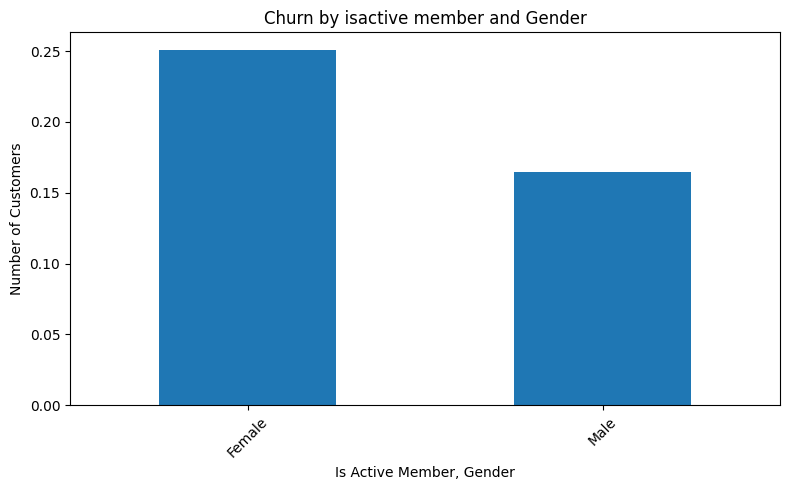

In [13]:
ax = gender_churn.plot(
    kind="bar",
    figsize=(8, 5),
    title="Churn by isactive member and Gender"
)

ax.set_xlabel("Is Active Member, Gender")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

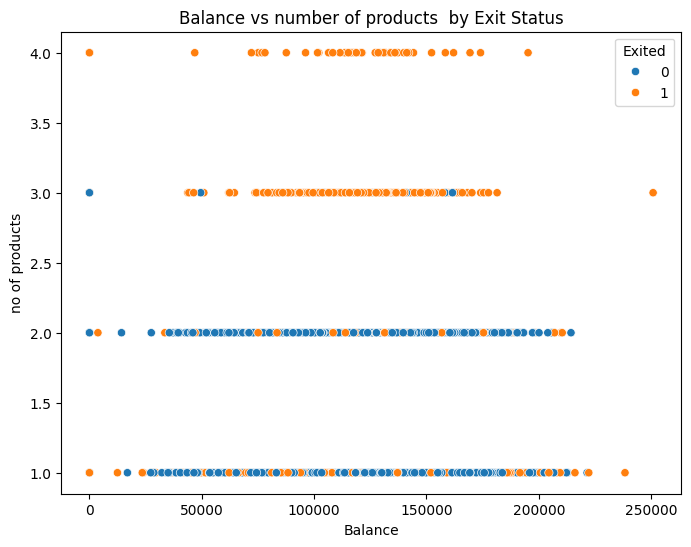

In [14]:
# balance and no of products  distribution in scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="balance", y="numofproducts", hue="exited")
plt.title("Balance vs number of products  by Exit Status")
plt.xlabel("Balance")
plt.ylabel("no of products")
plt.legend(title="Exited")
plt.show()

In [15]:
df

,creditscore,geography,gender,age,tenure(no_of_year_stay),balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# Feature Engineer

In [16]:
from sklearn.preprocessing import LabelEncoder

df_copy = df.copy()

# categorical column encoding
df_copy['gender_encoded'] = LabelEncoder().fit_transform(df_copy['gender'])
df_copy['geography_encoded'] = LabelEncoder().fit_transform(df_copy['geography'])

bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
df_copy['age_groups'] = pd.cut(df_copy['age'],bins=bins , 
                               labels=labels)


df_copy['zero_balance'] = (df_copy['balance'] == 0).astype(int)
df_copy['high_balance'] = (df_copy['balance'] > df_copy['balance'].quantile(0.75)).astype(int)

df_copy['balance_per_products'] = df_copy['balance'] / (df_copy['numofproducts'] + 1) # to avoid division by zero

df_copy['salary_balance_ratio'] = df_copy['estimatedsalary'] / (df_copy['balance'] + 1) # to avoid division by zero


# tenure bucket
tenure_bins = [-1 , 0, 2, 5, 10,100]
labels = ['0','1-2','3-5','6-10','10+']
df_copy['tenure_bucket'] = pd.cut(df_copy['tenure(no_of_year_stay)'], bins=tenure_bins, labels=labels)

# quic check
df_copy[['gender','gender_encoded','geography','geography_encoded','age','age_groups','balance_per_products','salary_balance_ratio',"balance",'zero_balance',"high_balance",'tenure(no_of_year_stay)','tenure_bucket']].head(10)

,gender,gender_encoded,geography,geography_encoded,age,age_groups,balance_per_products,salary_balance_ratio,balance,zero_balance,high_balance,tenure(no_of_year_stay),tenure_bucket
0,Female,0,France,0,42,35-44,0.000000,101348.880000,0.00,1,0,2,1-2
1,Female,0,Spain,2,41,35-44,41903.930000,1.342848,83807.86,0,0,1,1-2
2,Female,0,France,0,42,35-44,39915.200000,0.713581,159660.80,0,1,8,6-10
3,Female,0,France,0,39,35-44,0.000000,93826.630000,0.00,1,0,1,1-2
4,Female,0,Spain,2,43,35-44,62755.410000,0.630093,125510.82,0,0,2,1-2
5,Male,1,Spain,2,44,35-44,37918.593333,1.316464,113755.78,0,0,8,6-10
6,Male,1,France,0,50,45-54,0.000000,10062.800000,0.00,1,0,7,6-10
7,Female,0,Germany,1,29,25-34,23009.348000,1.037368,115046.74,0,0,4,3-5
8,Male,1,France,0,44,35-44,47350.356667,0.527557,142051.07,0,1,4,3-5
9,Male,1,France,0,27,25-34,67301.940000,0.532861,134603.88,0,1,2,1-2


In [17]:
categorical_features = ['age_groups','gender_encoded','geography_encoded','tenure_bucket','zero_balance','hascrcard','isactivemember','high_balance']

numeric_features=["creditscore" , "age" , "tenure(no_of_year_stay)","balance","numofproducts","estimatedsalary",'balance_per_products','salary_balance_ratio']

print("Categorical Features:", categorical_features)
print("Numeric Features:", numeric_features)

Categorical Features: ['age_groups', 'gender_encoded', 'geography_encoded', 'tenure_bucket', 'zero_balance', 'hascrcard', 'isactivemember', 'high_balance']
Numeric Features: ['creditscore', 'age', 'tenure(no_of_year_stay)', 'balance', 'numofproducts', 'estimatedsalary', 'balance_per_products', 'salary_balance_ratio']


In [18]:
from sklearn.model_selection import train_test_split

all_features = categorical_features + numeric_features
target_variable = "exited"
x = df_copy[all_features]
x = pd.get_dummies(x , columns=['age_groups', 'tenure_bucket'],drop_first=True)
y = df_copy[target_variable]

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

print('Train shape:', x_train.shape, 'Test shape:', x_test.shape)
print('Train churn proportion:', y_train.mean(), 'Test churn proportion:', y_test.mean())

Train shape: (8000, 23) Test shape: (2000, 23)
Train churn proportion: 0.2055 Test churn proportion: 0.1965


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost  as xgb
from sklearn.metrics import accuracy_score , classification_report , roc_auc_score , confusion_matrix
import warnings
warnings.filterwarnings("ignore")
logistic_model = LogisticRegression(class_weight='balanced')
logistic_model.fit(x_train_scaled , y_train)
random_forest = RandomForestClassifier(class_weight='balanced')
random_forest.fit(x_train , y_train)
xgb_classification = xgb.XGBClassifier()
xgb_classification.fit(x_train , y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [22]:
def evaluate_model(model, x_test, y_test, modelname):
    
    prediction = model.predict(x_test)
    acc = accuracy_score(y_test, prediction)
    

    # ROC-AUC (only if model supports probabilities)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_test)[:, 1]
        roc = roc_auc_score(y_test, proba)
    else:
        roc = None  

    print(f"\n🔍 Model: {modelname}")
    print(f"Accuracy: {acc:.4f}")
    
    if roc is not None:
        print(f"ROC AUC: {roc:.4f}")

    print("\n📊 Classification Report:")
    print(classification_report(y_test, prediction))

    if hasattr(model, "predict_proba"):
        print("\n📈 Sample Probabilities:", proba[:5])

In [23]:
evaluate_model(logistic_model , x_test_scaled , y_test,"logistic_regression")
evaluate_model(random_forest , x_test , y_test,"RandomForest Classifier")
evaluate_model(xgb_classification , x_test , y_test,"XGB Classifier")


🔍 Model: logistic_regression
Accuracy: 0.7250
ROC AUC: 0.7842

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1607
           1       0.39      0.68      0.49       393

    accuracy                           0.72      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.72      0.75      2000


📈 Sample Probabilities: [0.36439878 0.23653356 0.61143804 0.7505371  0.24909654]

🔍 Model: RandomForest Classifier
Accuracy: 0.8565
ROC AUC: 0.8538

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.76      0.39      0.52       393

    accuracy                           0.86      2000
   macro avg       0.81      0.68      0.72      2000
weighted avg       0.85      0.86      0.84      2000


📈 Sample Probabilities: [0.01 0.03 0.15 0.23 0.08]

🔍 Model: XGB Classifier
Accur

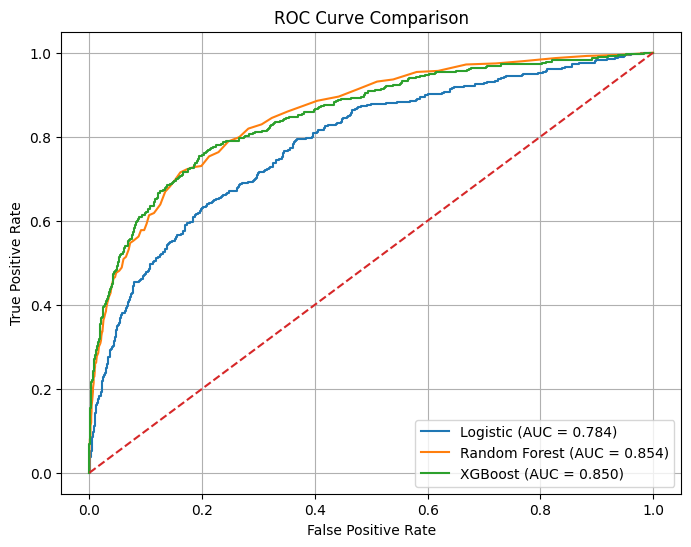

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Get Probabilities
log_proba = logistic_model.predict_proba(x_test_scaled)[:, 1]   # scaled
rf_proba  = random_forest.predict_proba(x_test)[:, 1]           # unscaled
xgb_proba = xgb_classification.predict_proba(x_test)[:, 1]      # unscaled

# -----------------------------
# Compute ROC Curves
# -----------------------------
fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

# -----------------------------
# Compute AUC Scores
# -----------------------------
auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()

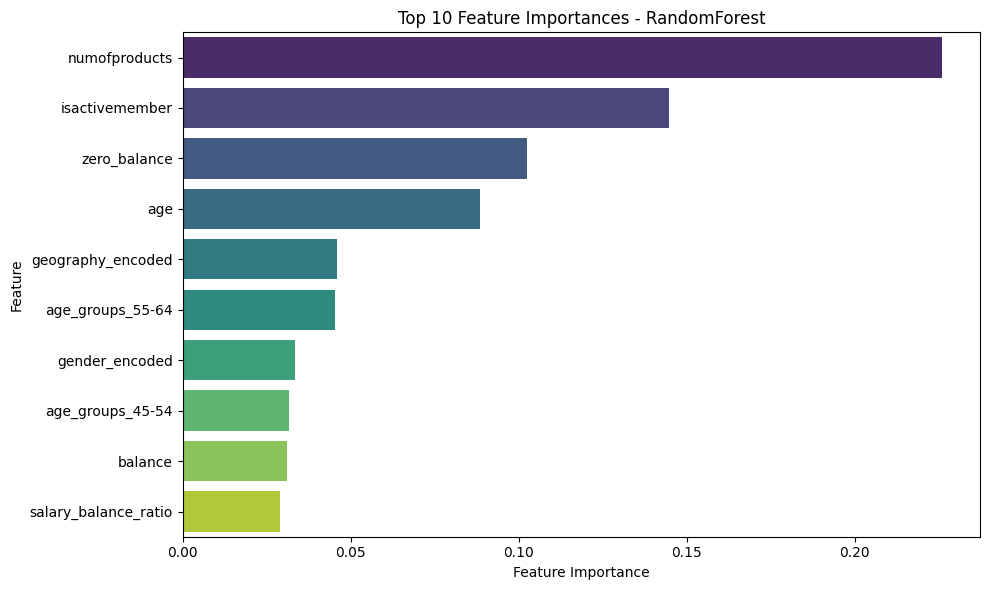

In [25]:
feature_names = x_train.columns
importances = xgb_classification.feature_importances_

fi_df = pd.DataFrame({
"feature": feature_names,
"importance": importances
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=fi_df, palette="viridis")
plt.title("Top 10 Feature Importances - RandomForest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()